In [1]:
# Imports

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

In [2]:
# Gray field stars as points, colored cluster members

def plot_membership(data):
    with fits.open(data) as hdul:
        data = hdul[1].data

    bp_rp = data["GAIAEDR3_BP"] - data["GAIAEDR3_RP"]
    G = data["GAIAEDR3_G"]
    dist = data["dist"]
    MG = G - 5*np.log10(dist) + 5

    mem = data["MemBool"] == 1
    field = data["MemBool"] != 1

    plt.scatter(bp_rp[mem], MG[mem], s=3, marker='o', zorder=2)
    plt.plot(bp_rp[field], MG[field], '.', color='0.8', markersize=3, zorder=1)
   
    plt.xlabel("BP - RP")
    plt.ylabel("M_G")
    plt.gca().invert_yaxis()

    plt.show()

In [54]:
def plot_rv_numbers(filename):
    with fits.open(filename) as hdul:
        data = hdul[1].data

    ids = data["GAIAEDR3_ID"]
    rv = data["vrad"]

    counts = {}
    has_any_rv = {}
    first_index = {}

    for i, star_id in enumerate(ids):
        if star_id not in first_index:
            first_index[star_id] = i
            counts[star_id] = 0
            has_any_rv[star_id] = False

        if np.isfinite(rv[i]):
            counts[star_id] += 1
            has_any_rv[star_id] = True

    unique_idx = np.array(list(first_index.values()))
    unique_data = data[unique_idx]
    unique_ids = unique_data["GAIAEDR3_ID"]

    bp_rp = unique_data["GAIAEDR3_BP"] - unique_data["GAIAEDR3_RP"]
    G = unique_data["GAIAEDR3_G"]
    dist = unique_data["dist"]
    MG = G - 5 * np.log10(dist) + 5

    mem = unique_data["MemBool"] == 1

    rv_counts = np.array([counts[s] for s in unique_ids])
    has_rv_flag = np.array([has_any_rv[s] for s in unique_ids])

    has_rv = mem & has_rv_flag
    no_rv = mem & ~has_rv_flag

    plt.figure(figsize=(8, 6))

    order = np.argsort(rv_counts[has_rv])

    sc = plt.scatter(bp_rp[has_rv][order],
                 MG[has_rv][order],
                 c=rv_counts[has_rv][order],
                 cmap='viridis',
                 s=16,
                 edgecolors='none')

    
    plt.colorbar(sc, label="Number of RV data points")
    plt.xlabel("BP - RP")
    plt.ylabel("M_G")
    plt.gca().invert_yaxis()
    plt.title("M_G vs BP-RP")
    plt.show()

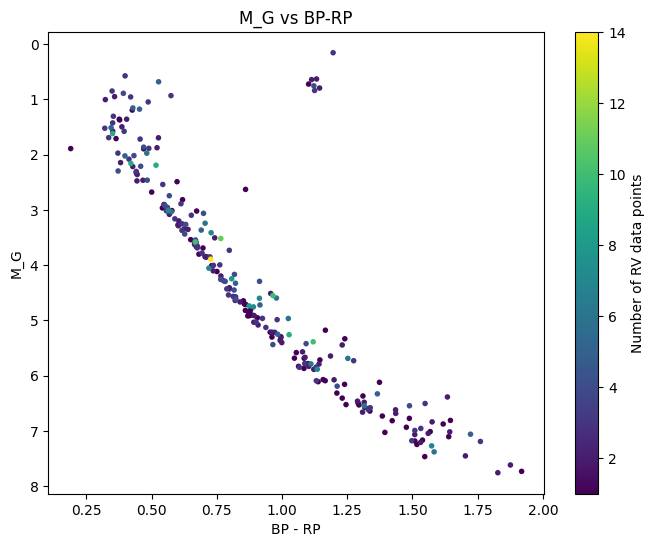

In [56]:
plot_rv_numbers("rcat_ngc6811_v0.fits")

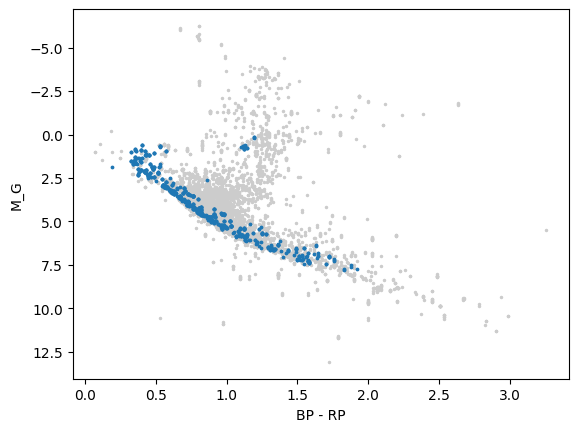

In [4]:
plot_membership("rcat_ngc6811_v0.fits")